In [1]:
# %cd ~/repos/foo_cleaned

In [2]:
import os
#os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".20"

In [3]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import util.functions as functions
import pybamm
import numpy as np
from tqdm import trange
import optuna

In [4]:
import jax
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())

All devices: [CudaDevice(id=0)]
Default backend: gpu


In [ ]:
from models.FNO import CAPE_FNO
from util.FNO_util import train_test_split, normalise_diffusion, preprocess_data, data_loader, remove_padding
from training.scheduler import cosine_schedule_with_warmup
from util.plotting import create_plot_FNO_results, plot_losses

In [6]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Prada2013")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600

In [42]:
family = "CC"
N_total = 33000
data = np.load(f"../data/{family}_{N_total}.npz")
random_seed = 42

In [43]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=0.1, seed=random_seed)  # noqa: F405

In [44]:
train_data.keys()

dict_keys(['soc', 'Dan', 'Dca', 'cn_anode', 'c0_anode', 'cn_cathode', 'c0_cathode', 'current'])

In [58]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])

train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])

train_D_anode = np.array(train_data["Dan"])
test_D_anode = np.array(test_data["Dan"])

#####Cathode data
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])
train_D_cathode = np.array(train_data["Dca"])
test_D_cathode = np.array(test_data["Dca"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

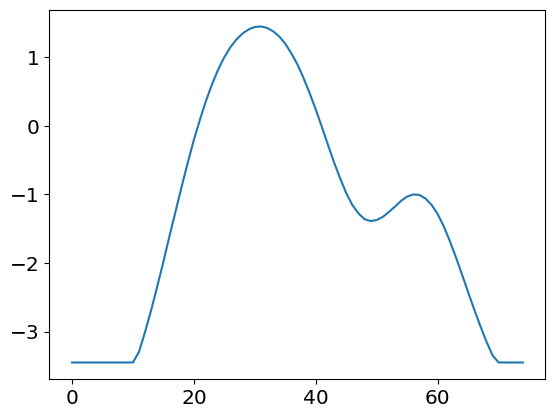

In [47]:
plt.plot(train_I[1])

In [ ]:
train_D_anode = normalise_diffusion(train_D_anode)
test_D_anode = normalise_diffusion(test_D_anode)

In [50]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [51]:
def loss_fn(params, X_batch, D_batch, Y_batch):
    preds = model.apply(params, X_batch, D_batch)  # (batch_size, H, W, 1)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [52]:
@jax.jit
def train_step(params, opt_state, X_batch, D_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch,D_batch, Y_batch)
    
    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [53]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [ ]:
X_train, Y_train = preprocess_data(train_I, train_c0_anode, train_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_anode, test_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [55]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (29700, 24, 85, 4) dtype: float64
Y_train shape: (29700, 24, 85, 1) dtype: float64


In [56]:
# Assume these hyperparameters
k_modes = 10
fno_depth = 6
hidden_channels = 64
input_channels = X_train.shape[-1]  # should be 4
output_channels = 1
param_channels = 50
cape_hidden_size = 32

In [57]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
dummy_D = jax.random.normal(init_key, (1,1))
params = model.init(init_key, X_train[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_train[:1,...], dummy_D)

In [ ]:

num_epochs = 25
batch_size = 20

warmup_steps = N_total/batch_size         # ~1 epoch, if 11,734 steps is an epoch
peak_lr = 1e-2                  # try bigger than your current 4e-3
total_steps = 25 * warmup_steps       # ~293,350
end_lr = 1e-4                   # final LR

scheduler = cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

optimizer = optax.adam(scheduler)
# Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

# Setup optimizer (Adam)

# learning_rate = 4e-3
# optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


Training:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
train_losses = []
test_losses = []
pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, Y_batch in data_loader(X_train, train_D_anode, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch),jnp.array(D_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
        if count % 1000 == 0:
            print()
    
    print(f"Training Iterations per Epoch: {count}")

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, Y_batch in data_loader(X_test,test_D_anode, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)


Training Iterations per Epoch: 1485


Epoch 1/25 | Train Loss: 0.1084 | Test Loss: 0.1347:   4%|▍         | 1/25 [00:27<11:11, 27.98s/it]


Training Iterations per Epoch: 1485


Epoch 2/25 | Train Loss: 0.0774 | Test Loss: 0.0549:   8%|▊         | 2/25 [00:51<09:36, 25.09s/it]


Training Iterations per Epoch: 1485


...

Epoch 23/25 | Train Loss: 0.0039 | Test Loss: 0.0033:  92%|█████████▏| 23/25 [08:57<00:46, 23.15s/it]


Training Iterations per Epoch: 1485


Epoch 24/25 | Train Loss: 0.0032 | Test Loss: 0.0031:  96%|█████████▌| 24/25 [09:20<00:23, 23.15s/it]


Training Iterations per Epoch: 1485


Epoch 25/25 | Train Loss: 0.0027 | Test Loss: 0.0038: 100%|██████████| 25/25 [09:43<00:00, 23.34s/it]


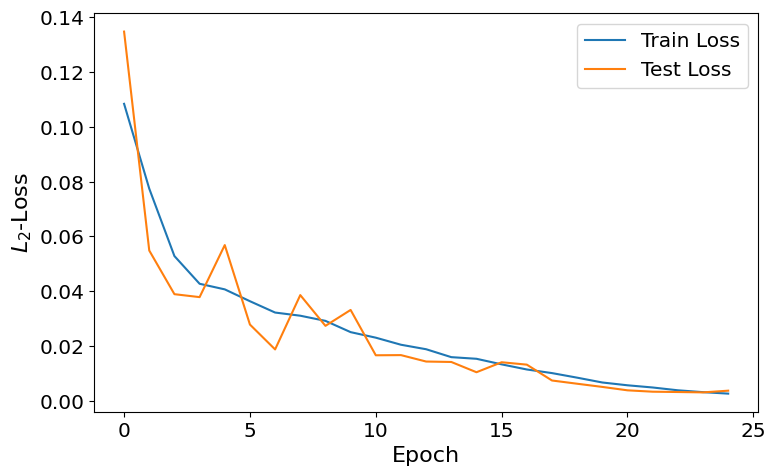

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [ ]:
train_idx = np.random.randint(0, N_total)
test_idx = np.random.randint(0, N_total)

In [ ]:
c_train_true = train_cn_anode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...], train_D_anode[train_idx][None,...])

c_test_true = test_cn_anode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...], test_D_anode[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)


In [79]:
c_train_pred_reshaped = jnp.squeeze(c_train_pred_reshaped, axis=(0,-1))  # (20,75)
c_test_pred_reshaped = jnp.squeeze(c_test_pred_reshaped, axis=(0,-1))  # (20,75)

In [33]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [34]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


In [ ]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, Ran)

plt.show()

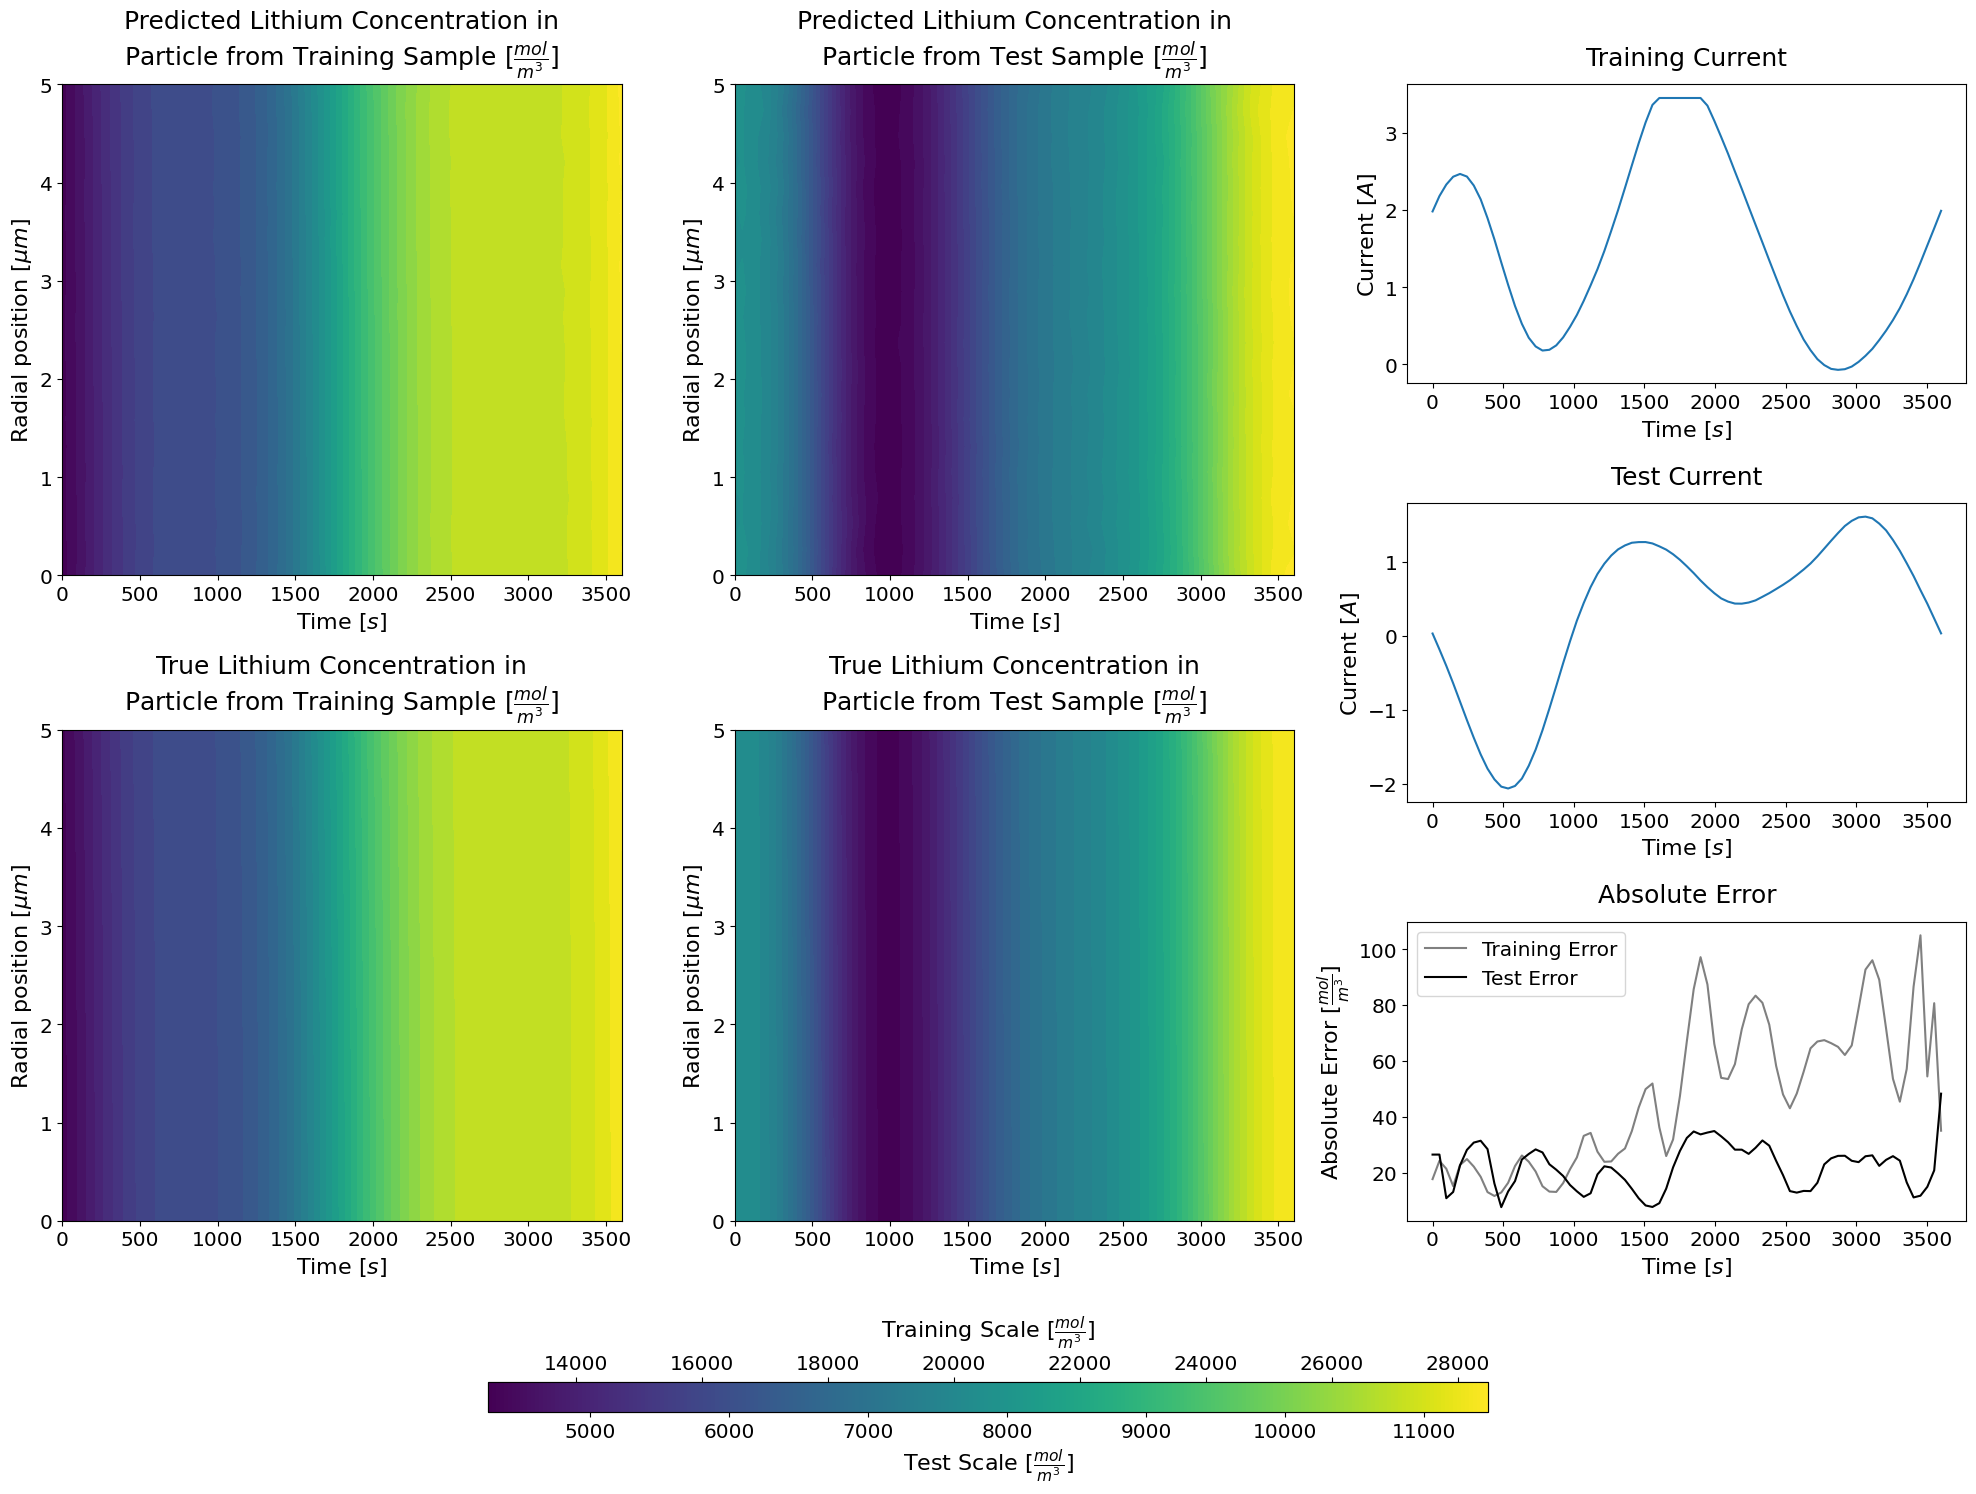

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import jax.numpy as jnp
# import numpy as np
# from matplotlib.cm import ScalarMappable
# from matplotlib.colors import Normalize

# #t_plot = np.linspace(0,1800,75)

# T_plot, R_plot = jnp.meshgrid(t, r)

# # Extract data for anode and cathode
# a_data = np.concatenate([
#     c_train_pred_scaled.ravel(),
#     c_train_true_scaled.ravel()
# ])
# c_data = np.concatenate([
#     c_test_pred_scaled.ravel(),
#     c_test_true_scaled.ravel()
# ])

# a_min, a_max = a_data.min(), a_data.max()
# c_min, c_max = c_data.min(), c_data.max()

# # Create separate norms for anode and cathode
# a_norm = Normalize(vmin=a_min, vmax=a_max)
# c_norm = Normalize(vmin=c_min, vmax=c_max)

# # Create the figure and main GridSpec
# fig = plt.figure(figsize=(20, 15))
# gs = gridspec.GridSpec(2, 3, figure=fig)

# def rasterize_contour(contour):
#     for c in contour.collections:
#         c.set_rasterized(True)

# # Anode Plots (use a_norm)
# ax1 = fig.add_subplot(gs[0,0])
# contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled,
#                         levels=50, cmap='viridis', norm=a_norm)
# #rasterize_contour(contour1)
# ax1.set_xlabel('Time [$s$]')
# ax1.set_ylabel('Radial position [$µm$]')
# ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# ax4 = fig.add_subplot(gs[1,0])
# contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled,
#                         levels=50, cmap='viridis', norm=a_norm)
# #rasterize_contour(contour3)
# ax4.set_xlabel('Time [$s$]')
# ax4.set_ylabel('Radial position [$µm$]')
# ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# # Cathode Plots (use c_norm)
# ax2 = fig.add_subplot(gs[0,1])
# contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled,
#                         levels=50, cmap='viridis', norm=c_norm)
# #rasterize_contour(contour2)
# ax2.set_xlabel('Time [$s$]')
# ax2.set_ylabel('Radial position [$µm$]')
# ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# ax5 = fig.add_subplot(gs[1,1])
# contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled,
#                         levels=50, cmap='viridis', norm=c_norm)
# #rasterize_contour(contour4)
# ax5.set_xlabel('Time [$s$]')
# ax5.set_ylabel('Radial position [$µm$]')
# ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# # Right column subdivided into three rows: Current, Voltage, Error
# right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

# ax_curr = fig.add_subplot(right_gs[0,0])
# ax_curr.plot(t, train_I[train_idx])
# ax_curr.set_title('Training Current', pad=14)
# ax_curr.set_xlabel('Time [$s$]')
# ax_curr.set_ylabel('Current [$A$]')

# ax_volt = fig.add_subplot(right_gs[1,0])
# ax_volt.plot(t, test_I[test_idx], linestyle='-')
# #ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
# ax_volt.set_title('Test Current', pad=14)
# ax_volt.set_xlabel('Time [$s$]')
# ax_volt.set_ylabel('Current [$A$]')

# ax_err = fig.add_subplot(right_gs[2,0])
# ax_err.plot(t, train_error_line, color='grey', label='Training Error', linestyle='-')
# ax_err.plot(t, test_error_line, color='black', label='Test Error', linestyle='-')
# ax_err.set_title('Absolute Error', pad=14)
# ax_err.set_xlabel('Time [$s$]')
# ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
# ax_err.legend()

# plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# # Create two separate ScalarMappables for the colorbars
# sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
# sm_anode.set_array([])
# sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
# sm_cathode.set_array([])

# # Add the two colorbars side by side at the bottom
# # Adjust positions as needed
# cbar_width = 0.5
# cbar_height = 0.02
# cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
# cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

# cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
# cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
# cbar_anode.ax.xaxis.set_label_position('top')
# cbar_anode.ax.xaxis.set_ticks_position('top')

# cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
# cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# # Save as rasterized SVG with a chosen DPI
# #fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
# plt.show()

In [83]:
filename = functions.save_model_params(params, directory = "../trained_models/cape_fno", family = family)

Saved model parameters to ../trained_models/cape_fno/anode_CC_2025-05-27_22-28-06.msgpack


In [ ]:
import gc
# del model
# del params
del X_train, Y_train, X_test, Y_test

#jax.clear_compilation_cache()
gc.collect()


6203

In [ ]:
X_train, Y_train = preprocess_data(train_I, train_c0_cathode, train_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_cathode, test_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [ ]:
model = CAPE_FNO(k_modes=k_modes, input_channels= input_channels, fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
dummy_D = jax.random.normal(init_key, (1,1))
params = model.init(init_key, X_train[:1,...], dummy_D)

# Forward pass
out = model.apply(params, X_train[:1,...], dummy_D)

Output shape: (1, 24, 85, 1)


In [ ]:
pbar = trange(num_epochs, desc="Training")

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, Y_batch in data_loader(X_train, train_D_cathode, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch),jnp.array(D_batch) , jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1
        if count % 1000 == 0:
            print()
    
    print(f"Training Iterations per Epoch: {count}")

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, Y_batch in data_loader(X_test,test_D_cathode, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Training:   0%|          | 0/25 [00:00<?, ?it/s]


ValueError: Dict key mismatch; expected keys: ['Dense_0', 'Dense_1', 'Dense_2', 'Dense_3', 'Dense_4', 'Dense_5', 'Dense_6', 'Dense_7', 'FourierLayer_0', 'FourierLayer_1', 'FourierLayer_2', 'FourierLayer_3', 'FourierLayer_4', 'FourierLayer_5']; dict: {'Dense_0': {'bias': Traced<ShapedArray(float32[50])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[1,50])>with<DynamicJaxprTrace>}, 'Dense_1': {'bias': Traced<ShapedArray(float32[50])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[50,50])>with<DynamicJaxprTrace>}, 'Dense_2': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[5,64])>with<DynamicJaxprTrace>}, 'Dense_3': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[64,64])>with<DynamicJaxprTrace>}, 'Dense_4': {'bias': Traced<ShapedArray(float32[64])>with<DynamicJaxprTrace>, 'kernel': Traced<ShapedArray(float32[64,64])>with<DynamicJaxprTrace>}, 'Dense_5': 

In [ ]:
filename = functions.save_model_params(params, directory = "../trained_models/cape_fno", prefix = "cathode", family = family)

Saved model parameters to ./trained_models/diff_D/cathode_CC__2025-03-24_16-22-03.msgpack


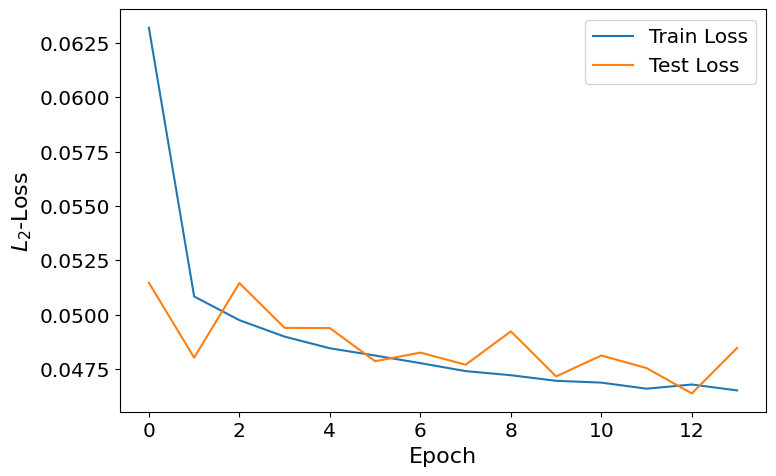

In [ ]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [ ]:
c_train_true = train_cn_cathode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...], train_D_cathode[train_idx][None,...])

c_test_true = test_cn_cathode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...], test_D_cathode[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)

In [ ]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [ ]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

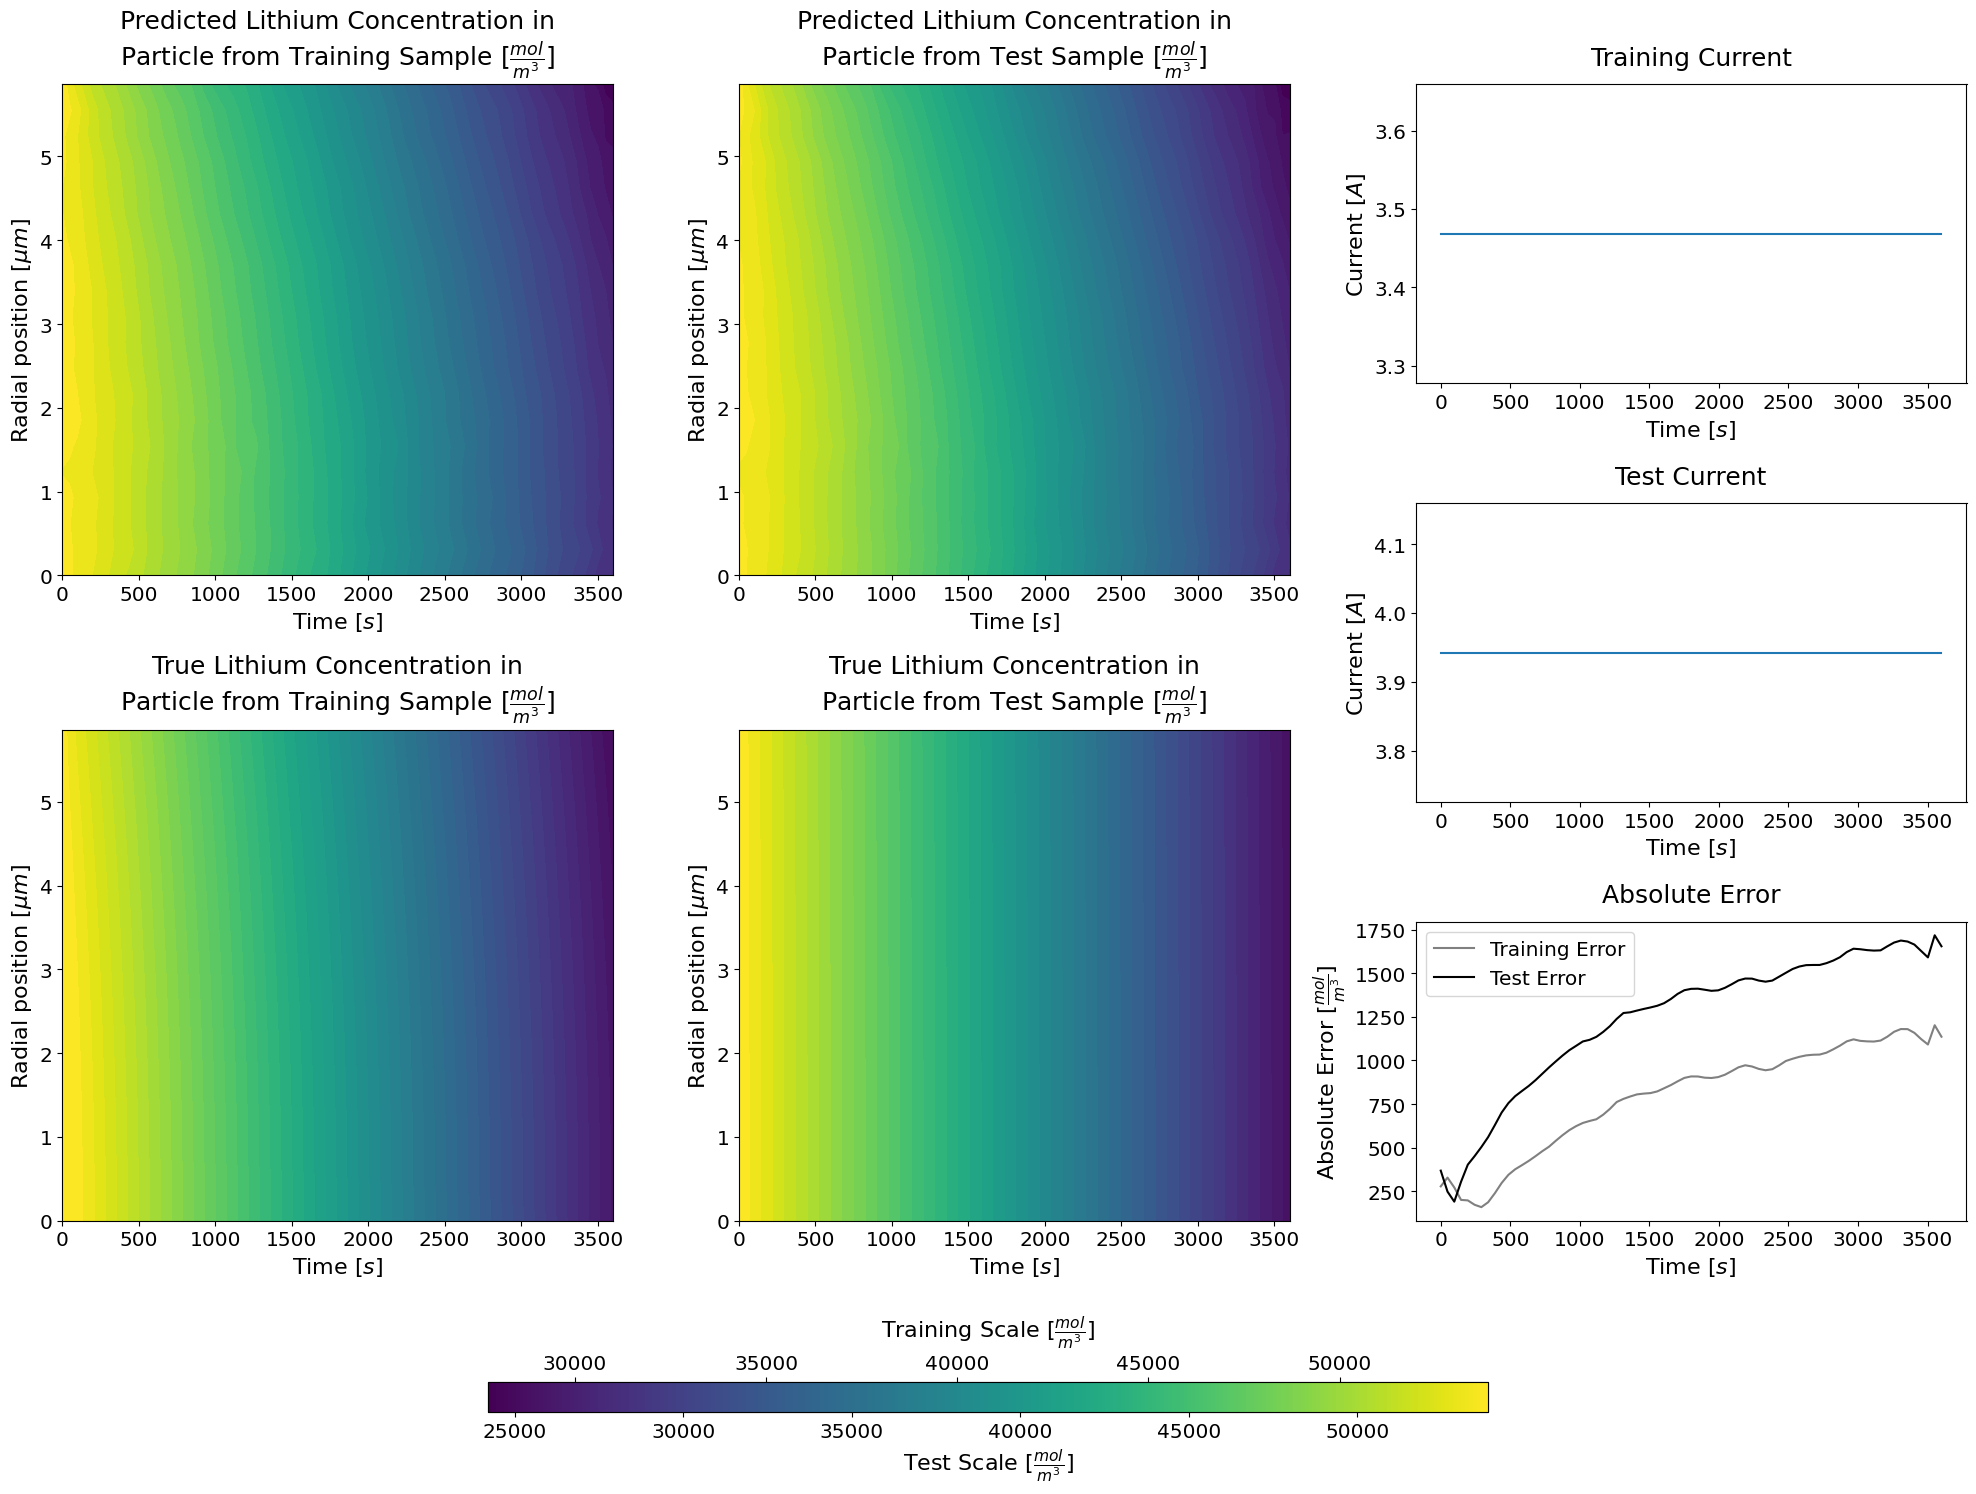

In [ ]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, Rca)

plt.show()